# Customer Churn Prediction - Model Training

The goal of this stage is to train machine learning models that can predict whether a customer is likely to churn.

The data has already been cleaned, explored, and transformed in the previous notebooks. Here, I will split the data into training and testing sets, train multiple classification models, and compare their performance using metrics that are useful for a churn prediction problem.

Since the dataset contains more customers who stayed than customers who churned, accuracy alone will not be enough to judge the models. I will also look at precision, recall, F1-score, ROC-AUC, and the confusion matrix.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score , f1_score , precision_score , recall_score





In [2]:
df = pd.read_csv("../data/processed/telco_features.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 37)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Avg Monthly Spend,...,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Group_Short-term,Tenure Group_Mid-term,Tenure Group_Long-term,City Freq,Churn Value
0,1,0,0,0,2,1,1,53.85,108.15,54.075000,...,0,0,0,0,1,0,0,0,305,1
1,0,0,0,1,2,1,1,70.70,151.65,75.825000,...,0,0,0,1,0,0,0,0,305,1
2,0,0,0,1,8,1,1,99.65,820.50,102.562500,...,0,0,0,1,0,0,0,0,305,1
3,0,0,1,1,28,1,1,104.80,3046.05,108.787500,...,0,0,0,1,0,0,1,0,305,1
4,1,0,0,1,49,1,1,103.70,5036.30,102.781633,...,0,0,0,0,0,0,0,1,305,1


In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes.value_counts())

Missing values: 0
Duplicate rows: 3

Data types:
int64      34
float64     3
Name: count, dtype: int64


In [4]:
duplicates = df[df.duplicated(keep= False)]
print("Duplicated Rows :" , len(duplicates)) 
duplicates

Duplicated Rows : 6


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Avg Monthly Spend,...,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Group_Short-term,Tenure Group_Mid-term,Tenure Group_Long-term,City Freq,Churn Value
1177,0,0,0,0,1,1,1,70.10,70.10,70.10,...,0,0,0,1,0,0,0,0,4,1
1656,0,0,0,0,1,1,1,70.10,70.10,70.10,...,0,0,0,1,0,0,0,0,4,1
2274,0,0,0,0,1,1,0,19.55,19.55,19.55,...,0,0,0,0,1,0,0,0,4,0
2364,1,0,0,0,1,1,0,20.05,20.05,20.05,...,0,0,0,0,1,0,0,0,4,0
2967,0,0,0,0,1,1,0,19.55,19.55,19.55,...,0,0,0,0,1,0,0,0,4,0
6087,1,0,0,0,1,1,0,20.05,20.05,20.05,...,0,0,0,0,1,0,0,0,4,0


In [5]:
# It is important to remove duplicate rows before the train-test split.
# Our dataset contains a few duplicated rows, so I will remove them
# before training the models.
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (7040, 37)


In [6]:
X  = df.drop("Churn Value" ,axis=1)
y= df ["Churn Value"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7040, 36)
y shape: (7040,)


In [7]:
# I am using stratify here because only about 27% of customers churned.
# Stratify keeps a similar class distribution in both training and testing sets.
# This helps us evaluate the models on a test set that represents the original data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5632, 36)
Testing set: (1408, 36)


In [8]:
# Hence training and testing sets have a similar class distribution.
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
Churn Value
0    0.73473
1    0.26527
Name: proportion, dtype: float64

Testing target distribution:
Churn Value
0    0.734375
1    0.265625
Name: proportion, dtype: float64


Now let's start training our models.
I am going to start with Logistic Regression because this is a binary classification problem where we want to predict whether a customer will churn or not.

Before training, let's have a look at tenure months, total charges and monthly charges.

In [9]:
df[["Tenure Months", "Total Charges" , "Monthly Charges"]].sample(5)

,Tenure Months,Total Charges,Monthly Charges
5331,35,700.45,20.75
3689,8,659.45,85.65
4550,72,7845.80,113.80
5682,1,19.65,19.65
3480,56,4824.45,85.65


### Feature Range Summary

| Column Name | Minimum Value | Maximum Value | Data Type |
| :--- | :---: | :---: | :--- |
| **Tenure Months** | 0 | ~72 | Integer |
| **Monthly Charges** | ~\$18 | ~\$118 | Float |
| **Total Charges** | \$0 | ~\$8,600 | Float |

If we directly give these to Logistic Regression, the larger-scale features can have an unwanted influence.

So we'll use StandardScaler.

In [10]:
scaler = StandardScaler()

In [11]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = LogisticRegression()
model.fit( X_train_scaled , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [13]:
y_pred = model.predict(X_test_scaled)
print("Predictions:", y_pred[:10])

Predictions: [0 1 0 0 0 0 1 0 0 0]


In [14]:
y_test.head(10)

4358    0
287     1
2232    0
4029    0
4641    0
4489    0
5398    0
2642    0
5090    0
430     1
Name: Churn Value, dtype: int64

In [15]:
accuracy = accuracy_score (y_test , y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8061079545454546
Precision: 0.6677740863787376
Recall   : 0.5374331550802139
F1 Score : 0.5955555555555555


In [16]:
cm = confusion_matrix(y_test , y_pred)
cm

array([[934, 100],
       [173, 201]])

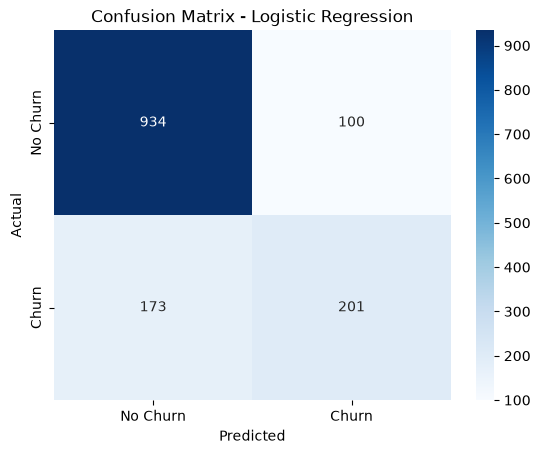

In [17]:
# Let's visualize the confusion matrix to understand the predictions

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    # Instead of showing 0 and 1, label the classes
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


| Metric | Score | Meaning |
| :--- | :---: | :--- |
| **Accuracy** | 80.61% | Overall, 80.61% predictions are correct |
| **Precision** | 66.78% | When model predicts churn, about 67% actually churn |
| **Recall** | 53.74% | Model catches only about 54% of actual churners |
| **F1 Score** | 59.56% | Balance between precision and recall |


The Logistic Regression baseline achieves around 80.6% accuracy, but its recall for churn is only 53.7%. This means the model is missing a significant number of customers who actually churn. Therefore, there is room for improvement, particularly in identifying churn customers.

## Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf = rf_model.fit(X_train_scaled , y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

In [19]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Results
Accuracy : 0.7862215909090909
Precision: 0.6254295532646048
Recall   : 0.48663101604278075
F1 Score : 0.5473684210526316


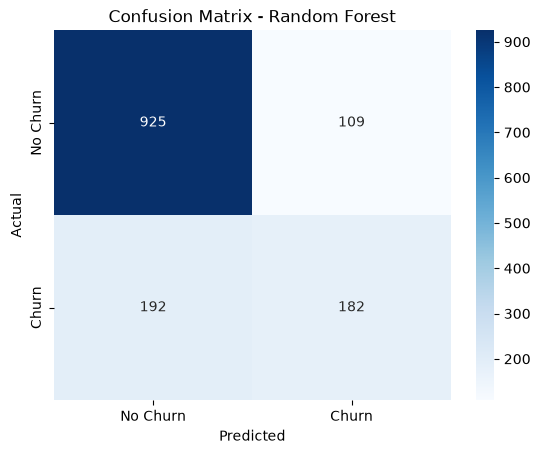

In [22]:
cm_rf = confusion_matrix(y_test , y_pred_rf)
# Lets visualize the confusion matrix to extract the info

sns.heatmap(
    cm_rf,
    annot = True,
    fmt= "d" ,
    cmap = "Blues",
    #instead of showing 0 and 1 lets me label them
    xticklabels = ["No Churn" , "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()



Random Forest achieved an accuracy of approximately 78.6%. However, the recall for churn is around 48.7%, meaning the model is able to identify less than half of the customers who actually churned. The model correctly identified 182 churn customers but missed 192 actual churn customers. This indicates that there is still room for improvement in identifying potential churners.

## Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier

In [24]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

In [25]:
# Evaluation
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Results
Accuracy : 0.7322443181818182
Precision: 0.4959349593495935
Recall   : 0.4893048128342246
F1 Score : 0.49259757738896365


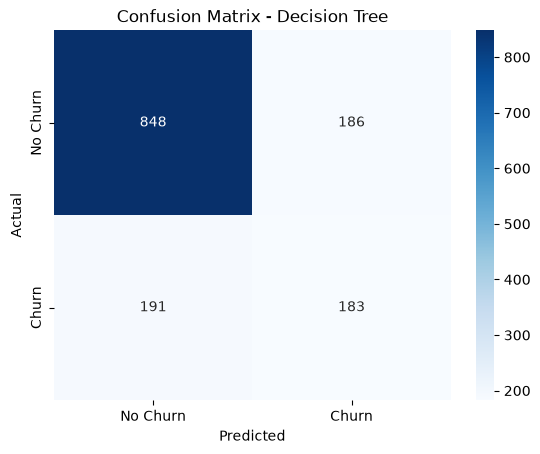

In [26]:
cm_dt = confusion_matrix(y_test , y_pred_dt)
# Lets visualize the confusion matrix to extract the info

sns.heatmap(
    cm_dt,
    annot = True,
    fmt= "d" ,
    cmap = "Blues",
    #instead of showing 0 and 1 lets me label them
    xticklabels = ["No Churn" , "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()



## Gradient Boosting

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [28]:
y_pred_gb = gb_model.predict(X_test_scaled)

In [29]:
# Evaluate
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("Accuracy :", accuracy_gb)
print("Precision:", precision_gb)
print("Recall   :", recall_gb)
print("F1 Score :", f1_gb)

Gradient Boosting Results
Accuracy : 0.7997159090909091
Precision: 0.6554054054054054
Recall   : 0.5187165775401069
F1 Score : 0.5791044776119403


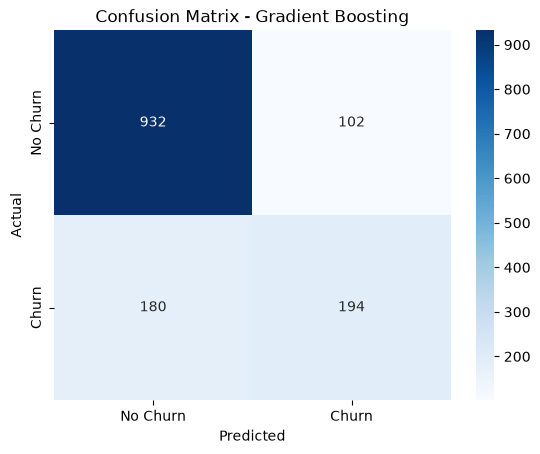

In [30]:
cm_gb = confusion_matrix(y_test , y_pred_gb)
# Lets visualize the confusion matrix to extract the info

sns.heatmap(
    cm_gb,
    annot = True,
    fmt= "d" ,
    cmap = "Blues",
    #instead of showing 0 and 1 lets me label them
    xticklabels = ["No Churn" , "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()



Gradient Boosting achieved an accuracy of approximately 80.0%. It correctly identified 194 churn customers but missed 180 actual churn customers. The recall of approximately 51.9% shows that the model still struggles to identify a significant portion of customers who actually churn.

## XGBoost

In [31]:
from xgboost import XGBClassifier

In [32]:
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [33]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [34]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)

XGBoost Results
Accuracy : 0.7833806818181818
Precision: 0.6005830903790087
Recall   : 0.5508021390374331
F1 Score : 0.5746164574616457


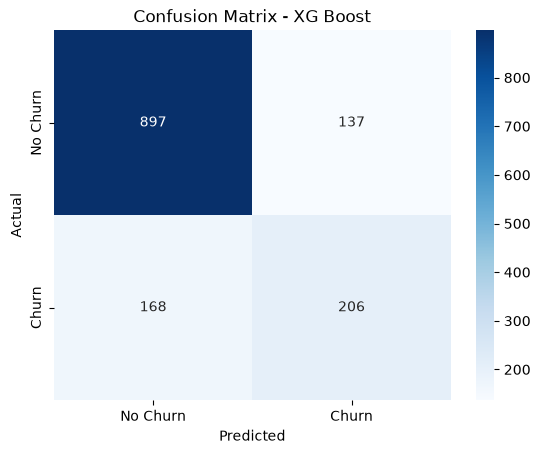

In [35]:
cm_xgb = confusion_matrix(y_test , y_pred_xgb)
# Lets visualize the confusion matrix to extract the info

sns.heatmap(
    cm_xgb,
    annot = True,
    fmt= "d" ,
    cmap = "Blues",
    #instead of showing 0 and 1 lets me label them
    xticklabels = ["No Churn" , "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XG Boost")
plt.show()



## K-Nearest Neighbors

In [36]:
from sklearn.neighbors import KNeighborsClassifier

In [37]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [38]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [39]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("KNN Results")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1 Score :", f1_knn)

KNN Results
Accuracy : 0.7684659090909091
Precision: 0.5666666666666667
Recall   : 0.5454545454545454
F1 Score : 0.555858310626703


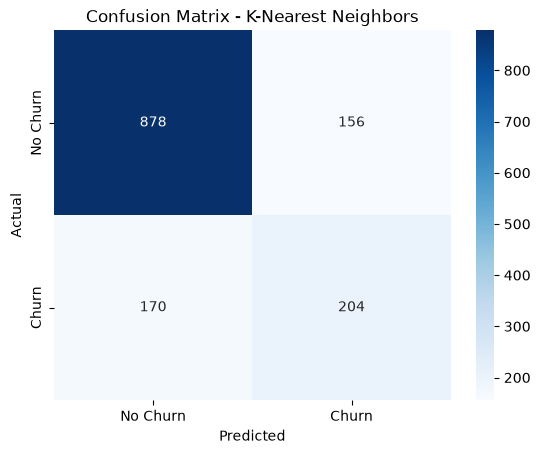

In [40]:
cm_knn = confusion_matrix(y_test , y_pred_knn)
# Lets visualize the confusion matrix to extract the info

sns.heatmap(
    cm_knn,
    annot = True,
    fmt= "d" ,
    cmap = "Blues",
    #instead of showing 0 and 1 lets me label them
    xticklabels = ["No Churn" , "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - K-Nearest Neighbors")
plt.show()



## Support Vector Machine (SVM)

In [41]:
from sklearn.svm import SVC

In [42]:
svm_model = SVC(
    kernel='rbf',
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [43]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [44]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Results")
print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1 Score :", f1_svm)

SVM Results
Accuracy : 0.8032670454545454
Precision: 0.6666666666666666
Recall   : 0.5187165775401069
F1 Score : 0.5834586466165413


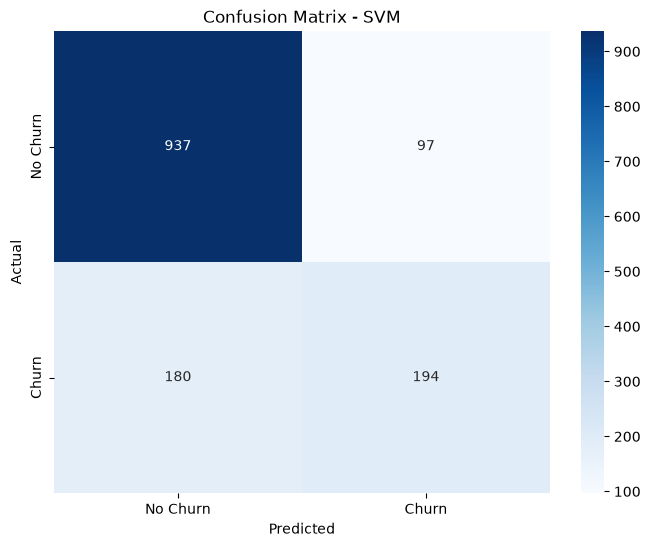

In [45]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

## Naive Bayes

In [46]:
from sklearn.naive_bayes import GaussianNB

In [47]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[4138.,1494.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.73,0.27]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,36
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 36)","[[-0. ,-0.09, 0.09,..., 0.04, 0.15,-0.02], [ 0. , 0.25,-0.24,...,-0.12,-0.42, 0.04]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 36)","[[1. ,0.83,1. ,...,1.06,1.1 ,0.96], [1. ,1.4 ,0.93,...,0.82,0.49,1.1 ]]"


In [48]:
y_pred_nb = nb_model.predict(X_test_scaled)

In [49]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Results")
print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

Naive Bayes Results
Accuracy : 0.7009943181818182
Precision: 0.46497764530551416
Recall   : 0.8342245989304813
F1 Score : 0.5971291866028708


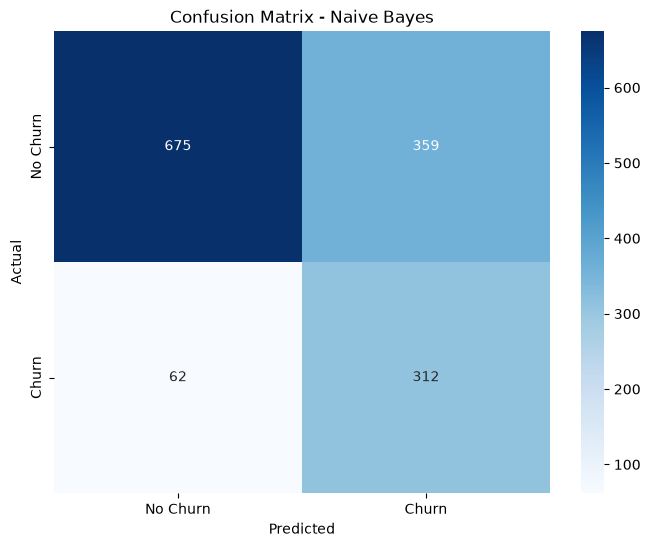

In [50]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

## Comparison of all algorithms

In [51]:
# Here I am creating a DataFrame consisting of 5 columns
# and 8 rows for the different algorithms.
model_results = pd.DataFrame(
    {
        'Model': [
            'Logistic Regression',
            'Random Forest',
            'Decision Tree',
            'Gradient Boosting',
            'XGBoost',
            'KNN',
            'SVM',
            'Naive Bayes'
        ],
        'Accuracy': [
            accuracy,
            accuracy_rf,
            accuracy_dt,
            accuracy_gb,
            accuracy_xgb,
            accuracy_knn,
            accuracy_svm, accuracy_nb
        ],
        'Precision': [
            precision, precision_rf, precision_dt, precision_gb,
            precision_xgb, precision_knn, precision_svm, precision_nb
        ],
        'Recall': [
            recall, recall_rf, recall_dt, recall_gb,
            recall_xgb, recall_knn, recall_svm, recall_nb
        ],
        'F1 Score': [
            f1, f1_rf, f1_dt, f1_gb,
            f1_xgb, f1_knn, f1_svm, f1_nb
        ]
    }
)
model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806108,0.667774,0.537433,0.595556
1,Random Forest,0.786222,0.625430,0.486631,0.547368
2,Decision Tree,0.732244,0.495935,0.489305,0.492598
3,Gradient Boosting,0.799716,0.655405,0.518717,0.579104
4,XGBoost,0.783381,0.600583,0.550802,0.574616
5,KNN,0.768466,0.566667,0.545455,0.555858
6,SVM,0.803267,0.666667,0.518717,0.583459
7,Naive Bayes,0.700994,0.464978,0.834225,0.597129


I am going to sort the DataFrame by F1 score because the dataset is imbalanced:

`No Churn` -> ~73%

`Churn`    -> ~27%

Accuracy alone can be misleading here, so I am using F1 Score as the main comparison metric because it balances precision and recall for the churn class.

In [52]:
model_results.sort_values(
    by = "F1 Score",
    ascending = False
)

,Model,Accuracy,Precision,Recall,F1 Score
7,Naive Bayes,0.700994,0.464978,0.834225,0.597129
0,Logistic Regression,0.806108,0.667774,0.537433,0.595556
6,SVM,0.803267,0.666667,0.518717,0.583459
3,Gradient Boosting,0.799716,0.655405,0.518717,0.579104
4,XGBoost,0.783381,0.600583,0.550802,0.574616
5,KNN,0.768466,0.566667,0.545455,0.555858
1,Random Forest,0.786222,0.625430,0.486631,0.547368
2,Decision Tree,0.732244,0.495935,0.489305,0.492598


## Model Comparison Observation

Naive Bayes achieved the highest recall of 83.42%, meaning it was able to identify most of the customers who actually churned. However, its precision and accuracy were considerably lower.

Logistic Regression provided a more balanced performance with 80.61% accuracy, 66.78% precision, 53.74% recall and a 59.56% F1 score.

Since this is a customer churn problem, recall is important because missing a customer who is likely to churn can result in a lost customer. Therefore, Naive Bayes is useful when the priority is identifying as many potential churners as possible, while Logistic Regression provides a better balance between precision and recall.

Further tuning will be performed before selecting the final model.

### Logistic Regression hyperparameter tuning

In [53]:
from sklearn.model_selection import GridSearchCV


In [54]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

In [55]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [56]:
grid_search = GridSearchCV(
    lr_model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with higherva

In [57]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'C': 100}
Best CV F1 Score: 0.6204211237852502


In [58]:
best_lr = grid_search.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test_scaled)

In [59]:
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
precision_lr_tuned = precision_score(y_test, y_pred_lr_tuned)
recall_lr_tuned = recall_score(y_test, y_pred_lr_tuned)
f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned)

print("Tuned Logistic Regression Results")
print("Accuracy :", accuracy_lr_tuned)
print("Precision:", precision_lr_tuned)
print("Recall   :", recall_lr_tuned)
print("F1 Score :", f1_lr_tuned)

Tuned Logistic Regression Results
Accuracy : 0.8046875
Precision: 0.6655518394648829
Recall   : 0.5320855614973262
F1 Score : 0.5913818722139673


Tuning barely changed the test-set result here. C=100 gives almost the same F1 score as the default C=1 baseline (59.14% vs 59.56%). The cross-validation F1 score was 0.62 for the tuned model, so the tuning step was still useful for selecting the model configuration.

### SVM tuning

In [60]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)

param_grid_svm = {
    "C": [1, 10, 100],
    "kernel": ["rbf"],
    "gamma": ["scale"]
}

In [61]:
grid_search_svm = GridSearchCV(
    svm_model,
    param_grid_svm,
    cv=5,
    scoring="f1"
)

grid_search_svm.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_svm.best_params_)
print("Best CV F1 Score:", grid_search_svm.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1 Score: 0.6103177204918806


In [62]:
best_svm = grid_search_svm.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test_scaled)

In [63]:
accuracy_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)
precision_svm_tuned = precision_score(y_test, y_pred_svm_tuned)
recall_svm_tuned = recall_score(y_test, y_pred_svm_tuned)
f1_svm_tuned = f1_score(y_test, y_pred_svm_tuned)

print("Tuned SVM Results")
print("Accuracy :", accuracy_svm_tuned)
print("Precision:", precision_svm_tuned)
print("Recall   :", recall_svm_tuned)
print("F1 Score :", f1_svm_tuned)

Tuned SVM Results
Accuracy : 0.7805397727272727
Precision: 0.5915492957746479
Recall   : 0.5614973262032086
F1 Score : 0.5761316872427984


In [72]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

In [73]:
grid_search_gb = GridSearchCV(
    gb_model,
    param_grid_gb,
    cv=5,
    scoring="f1"
)

grid_search_gb.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_gb.best_params_)
print("Best CV F1 Score:", grid_search_gb.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV F1 Score: 0.6013362338694233


In [74]:
best_gb = grid_search_gb.best_estimator_

y_pred_gb_tuned = best_gb.predict(X_test_scaled)

In [75]:
accuracy_gb_tuned = accuracy_score(y_test, y_pred_gb_tuned)
precision_gb_tuned = precision_score(y_test, y_pred_gb_tuned)
recall_gb_tuned = recall_score(y_test, y_pred_gb_tuned)
f1_gb_tuned = f1_score(y_test, y_pred_gb_tuned)

print("Tuned Gradient Boosting Results")
print("Accuracy :", accuracy_gb_tuned)
print("Precision:", precision_gb_tuned)
print("Recall   :", recall_gb_tuned)
print("F1 Score :", f1_gb_tuned)

Tuned Gradient Boosting Results
Accuracy : 0.7997159090909091
Precision: 0.6554054054054054
Recall   : 0.5187165775401069
F1 Score : 0.5791044776119403


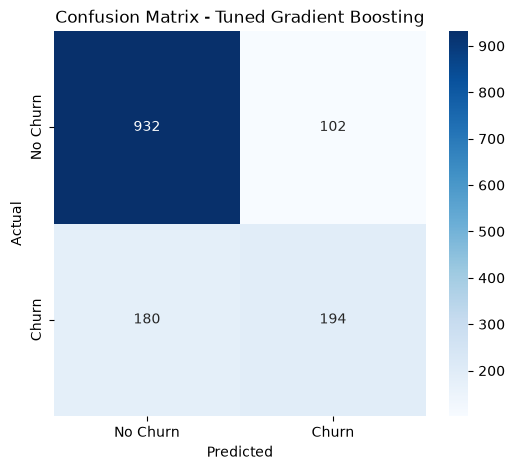

In [76]:
cm_gb_tuned = confusion_matrix(y_test, y_pred_gb_tuned)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gb_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Tuned Gradient Boosting ended up with the same parameters as the untuned baseline (`n_estimators=100`, `learning_rate=0.1`, `max_depth=3`), so the test-set results are identical to the baseline GB model above. GridSearchCV confirmed that the defaults were already the best option within the parameter grid.

## Final Model Comparison

Time to put everything together. For models that were tuned (Logistic Regression, SVM, Gradient Boosting) I'm using their tuned results below. For the rest I'm using the original baseline results since they weren't tuned.

In [77]:
final_results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression (Tuned)",
            "Random Forest",
            "Decision Tree",
            "Gradient Boosting (Tuned)",
            "XGBoost",
            "KNN",
            "SVM (Tuned)",
            "Naive Bayes"
        ],
        "Accuracy": [
            accuracy_lr_tuned, accuracy_rf, accuracy_dt, accuracy_gb_tuned,
            accuracy_xgb, accuracy_knn, accuracy_svm_tuned, accuracy_nb
        ],
        "Precision": [
            precision_lr_tuned, precision_rf, precision_dt, precision_gb_tuned,
            precision_xgb, precision_knn, precision_svm_tuned, precision_nb
        ],
        "Recall": [
            recall_lr_tuned, recall_rf, recall_dt, recall_gb_tuned,
            recall_xgb, recall_knn, recall_svm_tuned, recall_nb
        ],
        "F1 Score": [
            f1_lr_tuned, f1_rf, f1_dt, f1_gb_tuned,
            f1_xgb, f1_knn, f1_svm_tuned, f1_nb
        ]
    }
)

final_results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
7,Naive Bayes,0.700994,0.464978,0.834225,0.597129
0,Logistic Regression (Tuned),0.804688,0.665552,0.532086,0.591382
3,Gradient Boosting (Tuned),0.799716,0.655405,0.518717,0.579104
6,SVM (Tuned),0.780540,0.591549,0.561497,0.576132
4,XGBoost,0.783381,0.600583,0.550802,0.574616
5,KNN,0.768466,0.566667,0.545455,0.555858
1,Random Forest,0.786222,0.625430,0.486631,0.547368
2,Decision Tree,0.732244,0.495935,0.489305,0.492598


### Picking the final model

Naive Bayes technically has the highest baseline F1 score and the highest recall (83.42%), so it catches the most actual churners. But its precision is only 46.50%, which means many of the customers it flags as churners would not actually churn.

Tuned Logistic Regression has a slightly lower baseline F1 score (59.14% vs 59.71%), but it gives a more practical precision/recall balance and the highest baseline accuracy among the eight models. Its cross-validation F1 score was also strong at about 0.62.

For this project, I am choosing **Logistic Regression (Tuned, C=100)** as the final model because it provides a better balance between identifying churners and avoiding too many false churn predictions. I will then tune its classification threshold to put more emphasis on recall.

## Final Model

In [78]:
final_model = best_lr

final_model

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [79]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob_final = final_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_final)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8537117678089348


### ROC-AUC Observation

The final Logistic Regression model achieved a ROC-AUC score of 85.37%. This shows that the model has a good ability to distinguish between customers who churn and those who do not.

ROC-AUC also looks at the model's performance across different classification thresholds, so it gives us a better idea of how well the model separates the two classes rather than relying only on the default 0.5 threshold.

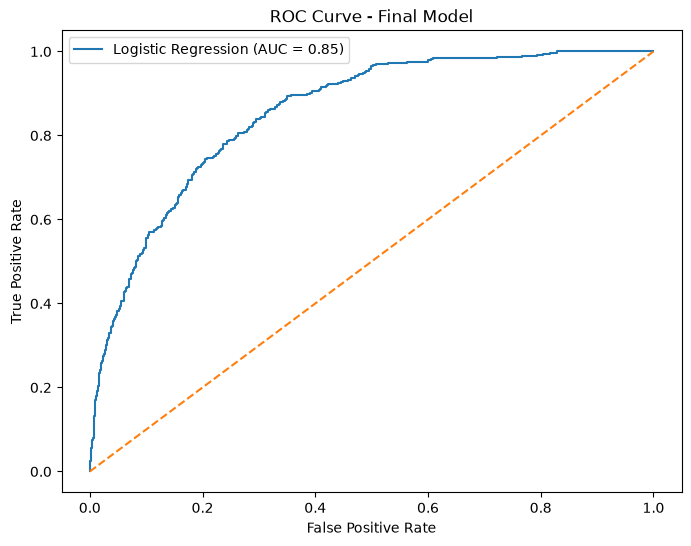

In [80]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.show()

### ROC Curve Observation

The ROC curve shows that the final Logistic Regression model performs considerably better than random guessing. With an AUC of 0.85, the model has a good ability to distinguish between customers who are likely to churn and those who are not.

Now let's do
### Threshold Tuning

We will try different thresholds and see what happens to Precision, Recall and F1.

In [81]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:
    y_pred_threshold = (y_prob_final >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print()

Threshold: 0.3
Precision: 0.546
Recall: 0.757
F1 Score: 0.635

Threshold: 0.35
Precision: 0.572
Recall: 0.725
F1 Score: 0.639

Threshold: 0.4
Precision: 0.599
Recall: 0.655
F1 Score: 0.626

Threshold: 0.45
Precision: 0.623
Recall: 0.596
F1 Score: 0.609

Threshold: 0.5
Precision: 0.666
Recall: 0.532
F1 Score: 0.591

Threshold: 0.55
Precision: 0.694
Recall: 0.479
F1 Score: 0.566

Threshold: 0.6
Precision: 0.714
Recall: 0.406
F1 Score: 0.518



### Threshold Tuning Observation

The default threshold of 0.5 gave an F1 score of 0.591 and recall of 0.532. On this test-set threshold sweep, a threshold of 0.35 gave the highest F1 score of 0.639 with a recall of 0.725.

The lower threshold increases the number of customers classified as potential churners, which improves recall but lowers precision. This is useful for a retention-focused use case.

**Note:** Because this threshold was selected using the test set, the 0.35 results should be treated as a threshold-tuning result rather than an unbiased final test estimate. In a production-quality evaluation, the threshold should be selected using a validation set or cross-validation and the untouched test set should be used only once for the final evaluation.

In [82]:
# final prediction after selecting threshold of 0.35
final_threshold = 0.35
y_pred_final = (y_prob_final >= final_threshold).astype(int)

print("Final Model Test Results")
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))

Final Model Test Results
Accuracy : 0.7826704545454546
Precision: 0.5717299578059072
Recall   : 0.7245989304812834
F1 Score : 0.6391509433962265


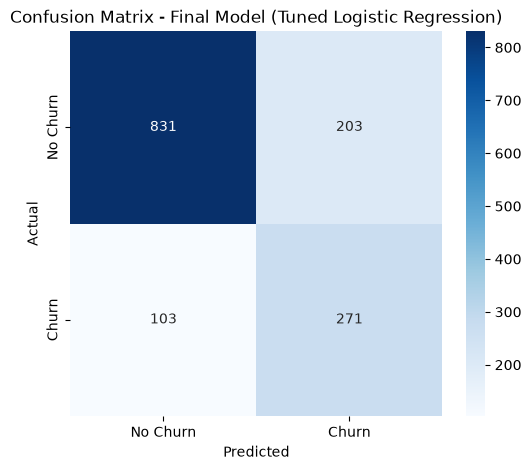

In [83]:
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model (Tuned Logistic Regression)")
plt.show()

### Final classification report

In [84]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_final,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      1034
       Churn       0.57      0.72      0.64       374

    accuracy                           0.78      1408
   macro avg       0.73      0.76      0.74      1408
weighted avg       0.81      0.78      0.79      1408



### Observation:

At a classification threshold of 0.35, the final model achieved an F1 score of 0.64 and recall of 0.72 for the churn class on the test set. Lowering the threshold helped the model identify more potential churn customers compared to the default threshold of 0.5. The ROC-AUC score of 0.85 also indicates that the model has good ability to distinguish between churn and non-churn customers.

**Evaluation note:** The threshold was selected from the same test set, so these threshold-tuned metrics are optimistic. For a stricter final evaluation, threshold selection should be moved to validation data and the test set should remain untouched.

## Saving the Final Model

Saving the model so it can be loaded later without retraining. Since Logistic Regression needs scaled input, the scaler has to be saved too, otherwise predictions on new data would be wrong. The classification threshold is saved as well because the final prediction uses 0.35 instead of the default 0.5.


In [85]:
print("Final Model:", final_model)
print("Final Scaler:", scaler)
print("Final threshold:", final_threshold )

Final Model: LogisticRegression(C=100, max_iter=1000, random_state=42)
Final Scaler: StandardScaler()
Final threshold: 0.35


In [86]:
import os
folder_path = r"../data/Models"

os.makedirs(folder_path, exist_ok=True)



In [87]:
# Saving the final model, scaler and threshold
import joblib

joblib.dump(final_model, os.path.join(folder_path, "final_model.pkl"))
joblib.dump(scaler, os.path.join(folder_path, "scaler.pkl"))
joblib.dump(final_threshold, os.path.join(folder_path, "threshold.pkl"))

print("All assets saved successfully")

All assets saved successfully
